# 00 — Каталог методов определения уровней (визуальный)

**Фаза 1, шаг 0.** Прежде чем тестировать «работают ли развороты от уровней», надо
увидеть, что вообще каждый метод считает уровнем. Один символ, одно окно, 4 причинных метода.

**Главный принцип — причинность (no lookahead).** Уровень обязан быть виден только из
ПРОШЛЫХ баров на момент закрытия текущего. Локальный экстремум графика опознаётся только
через несколько баров ПОСЛЕ него — поэтому пивоты рисуем с лагом подтверждения `k`.
Это ровно тот капкан (anchor-lookahead), что убил pump-исследование.

In [1]:
import sys; sys.path.insert(0, ".")
from _lab import *

SYM = "ETHUSDT"
df = ohlcv(SYM, "2024-09-15", "2024-11-01", tf="1h")
print(SYM, df.shape, "|", df.index[0], "\u2192", df.index[-1])
df.head(3)

ETHUSDT (1128, 5) | 2024-09-15 00:00:00+00:00 → 2024-10-31 23:00:00+00:00


,open,high,low,close,volume
timestamp,,,,,
2024-09-15 00:00:00+00:00,2416.77,2422.50,2415.17,2418.81,5987.58
2024-09-15 01:00:00+00:00,2418.81,2429.67,2418.81,2424.50,11105.72
2024-09-15 02:00:00+00:00,2424.50,2426.86,2418.52,2424.52,4663.18


## Метод 1+2 — свинг-пивоты (фракталы Вильямса = частный случай k=2)

Бар `i` — свинг-хай, если его `high` строго больше всех баров в окне `[i-k, i+k]`.
Это можно **подтвердить только через `k` баров** (нужно увидеть `k` баров справа).
Поэтому уровень `high[i]` становится известен трейдеру на баре `i+k`, не раньше —
горизонтальную линию рисуем от бара подтверждения вправо.

In [2]:
def pivots(df, k):
    """Causal swing pivots. is_hi[i]/is_lo[i] True if bar i is a strict extremum
    of the [i-k, i+k] window. Confirmable only at bar i+k (k bars of right context)."""
    h = df["high"].to_numpy(); l = df["low"].to_numpy()
    n = len(df)
    is_hi = np.zeros(n, bool); is_lo = np.zeros(n, bool)
    for i in range(k, n - k):
        wH = h[i - k:i + k + 1]; wL = l[i - k:i + k + 1]
        if h[i] == wH.max() and (wH == h[i]).sum() == 1:
            is_hi[i] = True
        if l[i] == wL.min() and (wL == l[i]).sum() == 1:
            is_lo[i] = True
    return is_hi, is_lo

for k in (2, 10):
    hi, lo = pivots(df, k)
    print(f"k={k:2d}: {hi.sum():3d} swing-highs, {lo.sum():3d} swing-lows  (\u043d\u0430 {len(df)} \u0431\u0430\u0440\u0430\u0445)")

k= 2: 154 swing-highs, 153 swing-lows  (на 1128 барах)
k=10:  37 swing-highs,  41 swing-lows  (на 1128 барах)


[saved] notebooks\levels\_out\00_fractals_k2.png


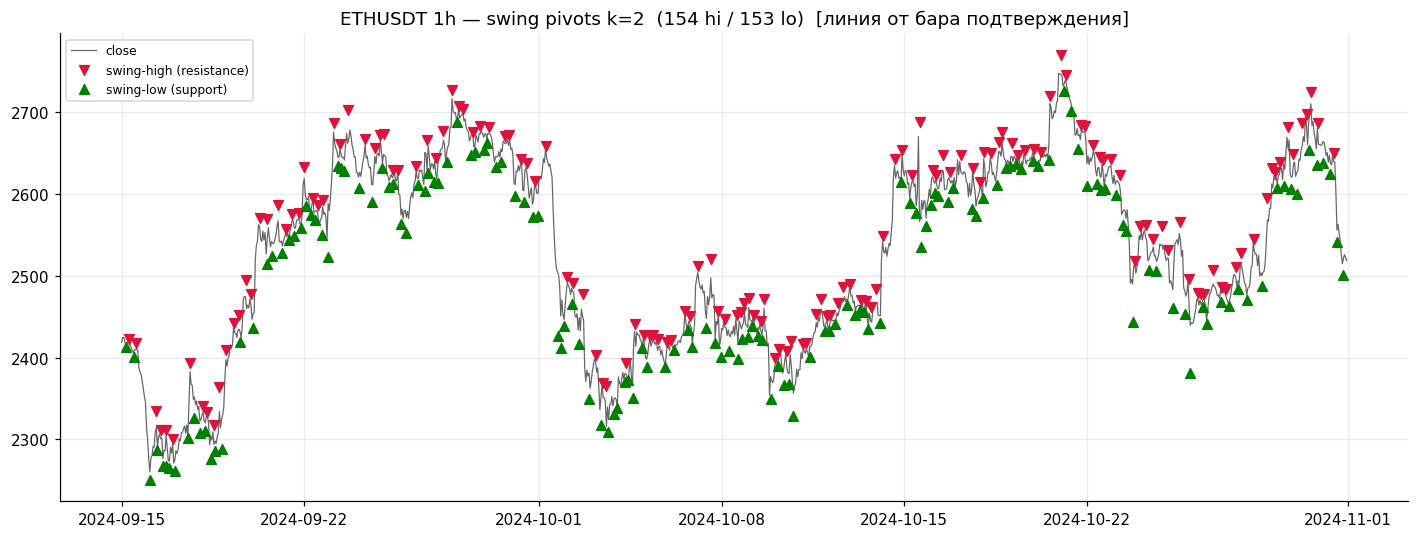

In [3]:
def plot_pivots(df, k, name, draw_lines=True, horizon=80):
    hi, lo = pivots(df, k)
    t = df.index; c = df["close"].to_numpy()
    h = df["high"].to_numpy(); l = df["low"].to_numpy()
    fig, ax = plt.subplots(figsize=(13, 5))
    ax.plot(t, c, lw=0.8, color="0.4", label="close")
    idx_hi = np.where(hi)[0]; idx_lo = np.where(lo)[0]
    ax.scatter(t[idx_hi], h[idx_hi], marker="v", s=40, color="crimson", zorder=5, label="swing-high (resistance)")
    ax.scatter(t[idx_lo], l[idx_lo], marker="^", s=40, color="green", zorder=5, label="swing-low (support)")
    if draw_lines:
        n = len(df)
        for i in idx_hi:  # line starts at CONFIRMATION bar i+k -> shows the lag
            c0 = min(i + k, n - 1); c1 = min(i + k + horizon, n - 1)
            ax.hlines(h[i], t[c0], t[c1], color="crimson", lw=0.7, alpha=0.35)
        for i in idx_lo:
            c0 = min(i + k, n - 1); c1 = min(i + k + horizon, n - 1)
            ax.hlines(l[i], t[c0], t[c1], color="green", lw=0.7, alpha=0.35)
    ax.set_title(f"{SYM} 1h \u2014 swing pivots k={k}  ({idx_hi.size} hi / {idx_lo.size} lo)  [\u043b\u0438\u043d\u0438\u044f \u043e\u0442 \u0431\u0430\u0440\u0430 \u043f\u043e\u0434\u0442\u0432\u0435\u0440\u0436\u0434\u0435\u043d\u0438\u044f]")
    ax.legend(loc="upper left", fontsize=8)
    show(name)

plot_pivots(df, k=2, name="00_fractals_k2", draw_lines=False)

[saved] notebooks\levels\_out\00_swings_k10.png


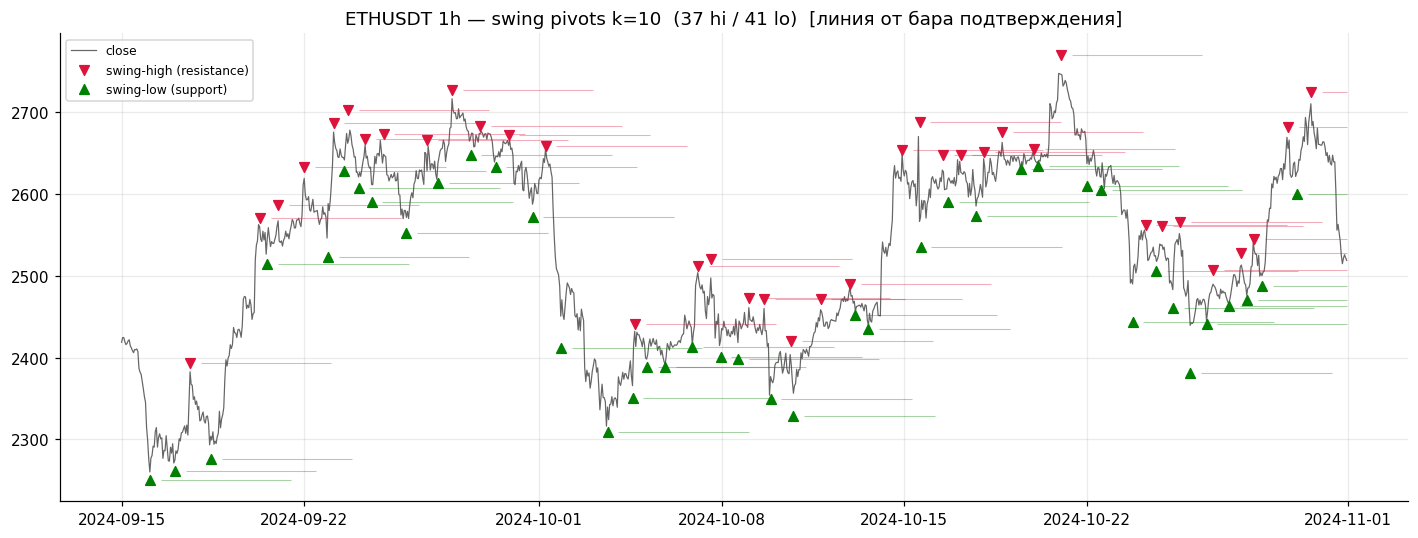

In [4]:
plot_pivots(df, k=10, name="00_swings_k10", draw_lines=True, horizon=120)

## Метод 3 — Donchian (rolling max/min со сдвигом)

Сопротивление = максимум `high` за прошлые `N` баров, поддержка = минимум `low`.
`.shift(1)` гарантирует, что текущий бар в расчёт уровня НЕ входит (причинность).
Это самый прозрачный метод: уровень всегда определён, легко проверить на lookahead.

[saved] notebooks\levels\_out\00_donchian.png


WindowsPath('C:/projects/researchlab/notebooks/levels/_out/00_donchian.png')

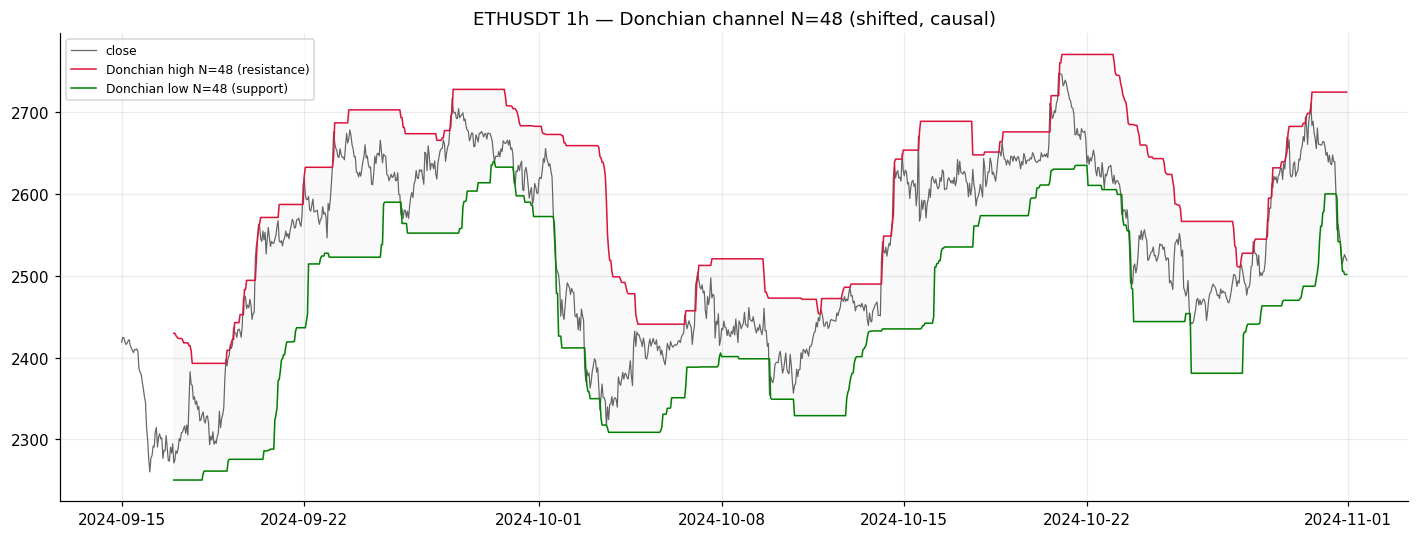

In [5]:
N = 48  # 48 \u0447\u0430\u0441\u043e\u0432 = 2 \u0434\u043d\u044f \u043d\u0430 1h
res = df["high"].rolling(N).max().shift(1)
sup = df["low"].rolling(N).min().shift(1)
t = df.index
fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(t, df["close"], lw=0.8, color="0.4", label="close")
ax.plot(t, res, lw=1.0, color="crimson", label=f"Donchian high N={N} (resistance)")
ax.plot(t, sup, lw=1.0, color="green", label=f"Donchian low N={N} (support)")
ax.fill_between(t, sup, res, color="0.7", alpha=0.08)
ax.set_title(f"{SYM} 1h \u2014 Donchian channel N={N} (shifted, causal)")
ax.legend(loc="upper left", fontsize=8)
show("00_donchian")

## Метод 4 — Volume / touch profile (HVN-зоны)

Уровни = ценовые зоны, где исторически провисало много объёма (high-volume nodes).
Строим гистограмму цены, взвешенную объёмом, по ПРОШЛОМУ окну; пики = зоны интереса.
Здесь профиль построен по всему показанному окну = «как видно на последнем баре, глядя
назад». В реальном тесте окно будет трейлинговым.

top HVN levels: [2376.  2436.7 2480.1 2532.1 2566.8 2627.5]
[saved] notebooks\levels\_out\00_volprofile.png


WindowsPath('C:/projects/researchlab/notebooks/levels/_out/00_volprofile.png')

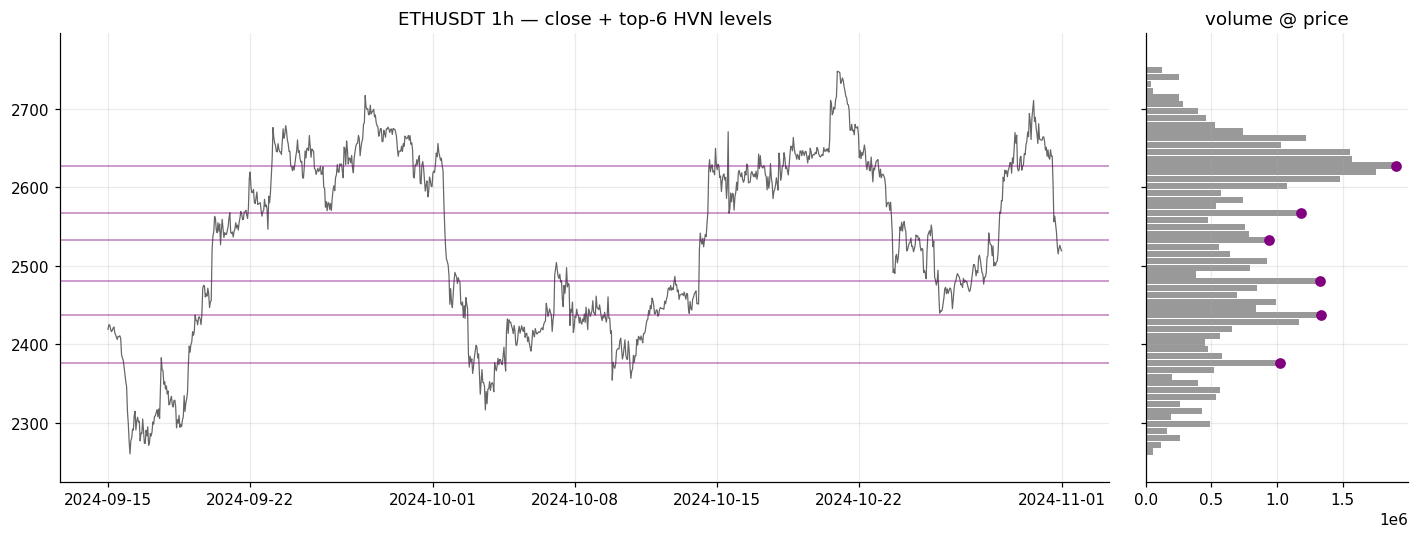

In [6]:
from scipy.signal import argrelextrema

tp = (df["high"] + df["low"] + df["close"]) / 3.0
lo_p, hi_p = df["low"].min(), df["high"].max()
edges = np.linspace(lo_p, hi_p, 61)
hist, _ = np.histogram(tp, bins=edges, weights=df["volume"].to_numpy())
centers = (edges[:-1] + edges[1:]) / 2.0
# HVN = local peaks of the volume-by-price histogram
peak_pos = argrelextrema(hist, np.greater, order=2)[0]
peak_pos = peak_pos[np.argsort(hist[peak_pos])[::-1]][:6]  # top-6 by volume
hvn = centers[peak_pos]
print("top HVN levels:", np.round(np.sort(hvn), 1))

fig, (axL, axR) = plt.subplots(1, 2, figsize=(13, 5), width_ratios=[4, 1], sharey=True)
axL.plot(df.index, df["close"], lw=0.8, color="0.4")
for lv in hvn:
    axL.axhline(lv, color="purple", lw=1.0, alpha=0.5)
axL.set_title(f"{SYM} 1h \u2014 close + top-6 HVN levels")
axR.barh(centers, hist, height=(edges[1] - edges[0]) * 0.9, color="0.6")
axR.scatter(hist[peak_pos], hvn, color="purple", zorder=5)
axR.set_title("volume @ price")
show("00_volprofile")

## Что дальше

Глядя на 4 картинки, обсуждаем: какие методы рисуют осмысленные/устойчивые уровни,
а какие шумят. Следующий шаг (nb 01) — **количественная оценка**: плотность уровней
(сколько времени цена «рядом с уровнем») и reaction-тест (forward-доходность после
касания против baseline). Только так выберем метод(ы) для самой стратегии разворота.